In [7]:
from langgraph.graph import StateGraph, START, MessagesState, END
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import RemoveMessage, HumanMessage
import os

In [8]:
load_dotenv()

True

In [9]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    google_api_key=os.getenv("GOOGLE_GENAI_KEY"),
)

In [10]:
class ChatState(MessagesState):
    summary: str 
    

In [24]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary: {state['summary']}"
        })
        print("Sumamry added to messages:", state["summary"])

    messages.extend(state["messages"])

    print(messages)

    response = llm.invoke(messages)

    return {
        "messages": [response]
    }

In [25]:
def summarize_messages(state : ChatState):

    existing_summary = state["summary"]

    if existing_summary:
        prompt = (f"Existing summary : \n{existing_summary}\n\n"
                  "Extend the summary using the new conversation above.")
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [HumanMessage(content=prompt)]

    response = llm.invoke(messages_for_summary)

    messages_to_delete = state["messages"][:-2]

    return {
        "summary" : response.content,
        "messages" : [RemoveMessage(id=m.id) for m in messages_to_delete]
    }


In [37]:
def should_summarize(state: ChatState):

    print("Checking summarization...")
    print("Number of messages:", len(state["messages"]))

    result = len(state["messages"]) > 6

    print("Should summarize:", result)

    return result

In [38]:
builder = StateGraph(ChatState)
builder.add_node("chat_node", chat_node)
builder.add_node("summarize_messages", summarize_messages)

builder.add_edge(START, "chat_node")
builder.add_conditional_edges(
    "chat_node", should_summarize, {
        
        True: "summarize_messages",
        False: "__end__"
    }
)

builder.add_edge("summarize_messages", "__end__")

In [39]:
checkpoint = InMemorySaver()
graph = builder.compile(checkpointer=checkpoint)

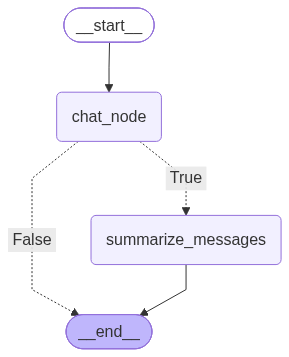

In [40]:
graph

In [41]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}



In [42]:
def show_state():
    snap = graph.get_state(config)
    values = snap.values
    print("\n--------STATE---------")
    print(f"Summary: {values.get('summary', 'No summary available')}`")
    print("num_messages:", len(values.get("messages", [])))
    print("Messages:")
    for msg in values.get("messages", []):
        print(msg.content[:80])

In [43]:
out = graph.invoke({
    "messages": [{
        "role": "user",
        "content": "Quantum Physics"
    }] , "summary": ''
}, config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='0f2c4aad-861b-4d5b-aca4-55307e156825')]
Checking summarization...
Number of messages: 2
Should summarize: False
{'messages': [HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='0f2c4aad-861b-4d5b-aca4-55307e156825'), AIMessage(content=[{'type': 'text', 'text': 'Quantum physics (also known as quantum mechanics) is the branch of science that deals with the behavior of matter and energy at the smallest scales—atoms, subatomic particles, and photons.\n\nWhile classical physics (Newton’s laws) accurately predicts the movement of planets, cars, and baseballs, it fails completely when applied to the subatomic world. In the quantum realm, the universe stops behaving like a predictable machine and starts acting more like a game of chance governed by waves of probability.\n\nHere are the core concepts that define quantum physics:\n\n---\n\n### 1. Wave-Particle Duality\nOn

In [44]:
out = graph.invoke({
    "messages": [{
        "role": "user",
        "content": "How is Albert Einstein related to Quantum Physics?"
    }] , "summary": ''
}, config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='0f2c4aad-861b-4d5b-aca4-55307e156825'), AIMessage(content=[{'type': 'text', 'text': 'Quantum physics (also known as quantum mechanics) is the branch of science that deals with the behavior of matter and energy at the smallest scales—atoms, subatomic particles, and photons.\n\nWhile classical physics (Newton’s laws) accurately predicts the movement of planets, cars, and baseballs, it fails completely when applied to the subatomic world. In the quantum realm, the universe stops behaving like a predictable machine and starts acting more like a game of chance governed by waves of probability.\n\nHere are the core concepts that define quantum physics:\n\n---\n\n### 1. Wave-Particle Duality\nOne of the most famous experiments in physics, the **Double-Slit Experiment**, showed that light and matter can exhibit the properties of both particles (tiny "billiards balls") and waves (like ripples in a pond). De

In [45]:
out = graph.invoke({
    "messages": [{
        "role": "user",
        "content": "Albert Einstein is known for his contributions to the theory of relativity, but he also made significant contributions to quantum mechanics. He proposed the idea of light quanta (photons) and explained the photoelectric effect, which provided evidence for the quantum nature of light. However, Einstein was skeptical of some aspects of quantum mechanics, particularly the idea of indeterminacy and randomness, famously stating 'God does not play dice with the universe.'"
    }] , "summary": ''
}, config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='0f2c4aad-861b-4d5b-aca4-55307e156825'), AIMessage(content=[{'type': 'text', 'text': 'Quantum physics (also known as quantum mechanics) is the branch of science that deals with the behavior of matter and energy at the smallest scales—atoms, subatomic particles, and photons.\n\nWhile classical physics (Newton’s laws) accurately predicts the movement of planets, cars, and baseballs, it fails completely when applied to the subatomic world. In the quantum realm, the universe stops behaving like a predictable machine and starts acting more like a game of chance governed by waves of probability.\n\nHere are the core concepts that define quantum physics:\n\n---\n\n### 1. Wave-Particle Duality\nOne of the most famous experiments in physics, the **Double-Slit Experiment**, showed that light and matter can exhibit the properties of both particles (tiny "billiards balls") and waves (like ripples in a pond). De

In [46]:
out = graph.invoke({
    "messages": [{
        "role": "user",
        "content": "Have I asked you about quantum physics before?"
    }] , "summary": ''
}, config=config)
print(out)
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='0f2c4aad-861b-4d5b-aca4-55307e156825'), AIMessage(content=[{'type': 'text', 'text': 'Quantum physics (also known as quantum mechanics) is the branch of science that deals with the behavior of matter and energy at the smallest scales—atoms, subatomic particles, and photons.\n\nWhile classical physics (Newton’s laws) accurately predicts the movement of planets, cars, and baseballs, it fails completely when applied to the subatomic world. In the quantum realm, the universe stops behaving like a predictable machine and starts acting more like a game of chance governed by waves of probability.\n\nHere are the core concepts that define quantum physics:\n\n---\n\n### 1. Wave-Particle Duality\nOne of the most famous experiments in physics, the **Double-Slit Experiment**, showed that light and matter can exhibit the properties of both particles (tiny "billiards balls") and waves (like ripples in a pond). De

In [47]:
out = graph.invoke({
    "messages": [{
        "role": "user",
        "content": "Discuss the topics we discussed"
    }] , "summary": ''
}, config=config)
print(out)
show_state()

[HumanMessage(content='Have I asked you about quantum physics before?', additional_kwargs={}, response_metadata={}, id='95cada1a-1388-443f-b5fd-572ee877ee5d'), AIMessage(content=[{'type': 'text', 'text': 'As an AI, I don’t have a long-term memory of our past conversations once a session is closed or cleared. Each time you start a new chat, it is like a "blank slate" for me.\n\nHowever, based on our current interaction, **this is the first time you have asked me about quantum physics in this specific session.**\n\nIf you have asked me about it in a previous, separate session, I wouldn\'t be able to recall those details or know that we\'ve had that conversation. I treat every new chat as a fresh start unless you provide context from previous ones!\n\n**Were you getting a sense of Déjà vu, or were you just curious if I keep track of our learning history?**', 'extras': {'signature': 'EnEKbwERTTIPihLF+t2wXGgZmH/psdJf3I3MbqyfVA1yiXPW3lRdD0YI/12WZO7uhCRg7SwYDNbZFgRkxRCG52N2bRHQdkSLswzbs31NdHK